In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]

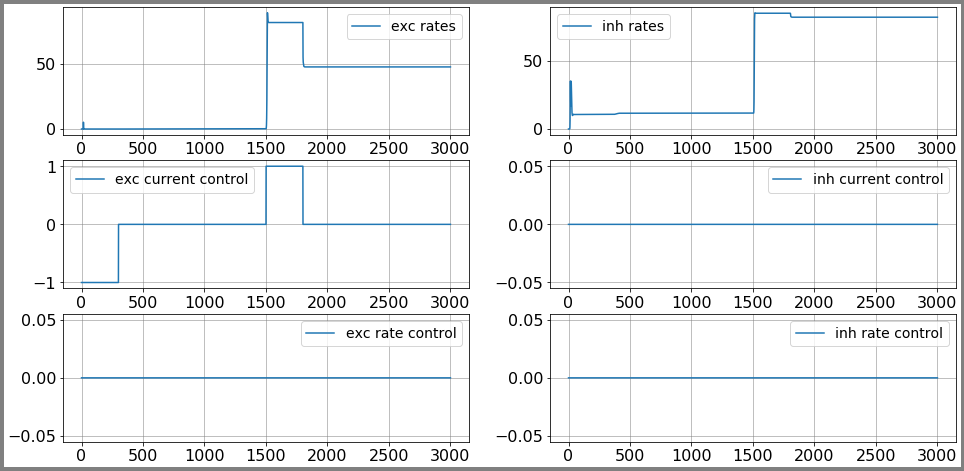

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


In [3]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]

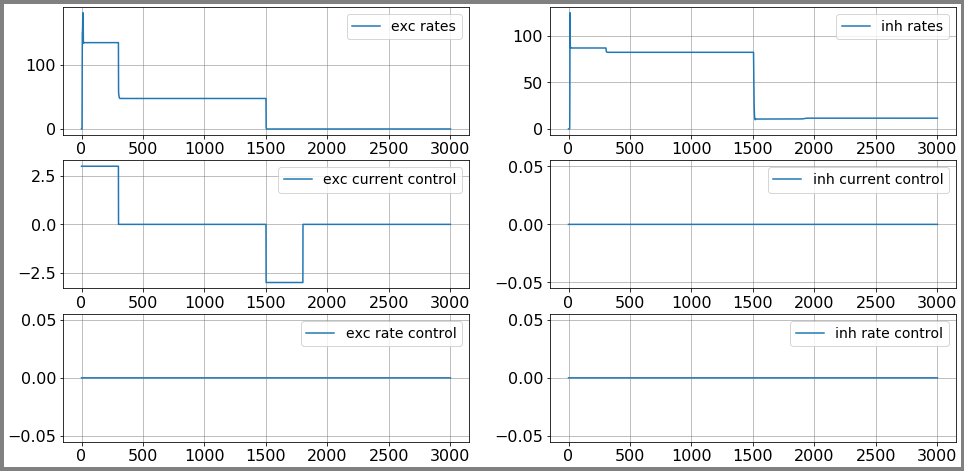

low state vars =  [ 8.2469e-02  1.1638e+01  4.3314e-01  7.5957e-01  0.0000e+00  1.6029e-02
  6.3812e-01  1.4997e-02  7.8014e-01  9.5893e-04  6.6523e-03  8.4016e-04
  6.5247e-03  0.0000e+00  0.0000e+00  7.1463e-01  5.5403e-01 -5.6298e+01
  2.7100e+01  6.3823e+00]


In [4]:
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]

print("low state vars = ", low_state_vars)

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [5]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 50

initVars = low_state_vars

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

sheet = "A"

target_rates = np.array( [steady_rates[0,0], steady_rates[0,1]])

In [6]:
def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
    elif cntrl_vars == [1]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [2]:
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
            
    return max_cntrl, min_cntrl        

## 0

set cost params
control input:  [0] , precision measure:  [0]
RUN  0 , total integrated cost =  112579.93927985422
RUN  1 , total integrated cost =  21940.085327196997
RUN  2 , total integrated cost =  21940.085327196986


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  21940.085327196986
Control only changes marginally.
RUN  3 , total integrated cost =  21940.085327196986
Improved over  3  iterations by  80.51154986621752  percent.
Problem in initial value trasfer:  Vmean_exc -56.19546146704652 -56.194298734685276


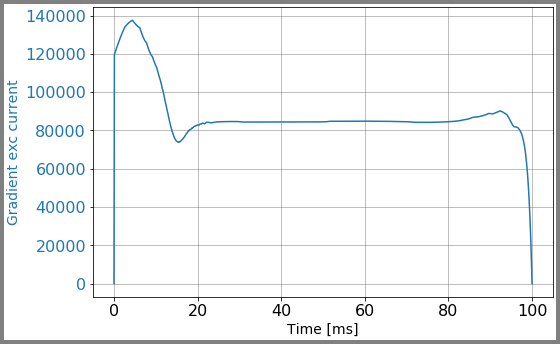

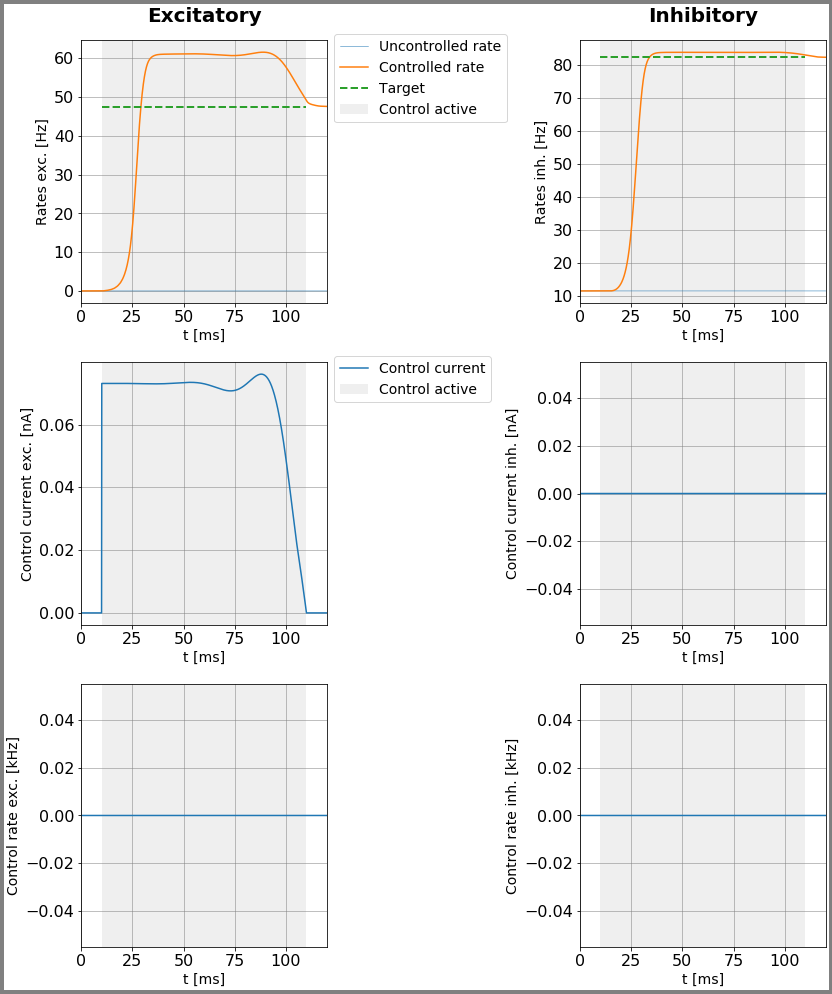

In [34]:
# B.0.a)

dur = 100
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]


case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.,
    crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  23618.310235643785
RUN  1 , total integrated cost =  1319.3072549925419
RUN  2 , total integrated cost =  1164.9193862981172
RUN  3 , total integrated cost =  1164.6455209192825
RUN  4 , total integrated cost =  1164.6455209192816
RUN  5 , total integrated cost =  1164.6455209192811


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  1164.6455209192811
Control only changes marginally.
RUN  6 , total integrated cost =  1164.6455209192811
Improved over  6  iterations by  95.06888719260853  percent.
Problem in initial value trasfer:  Vmean_exc -56.186163315571115 -56.18553264183135


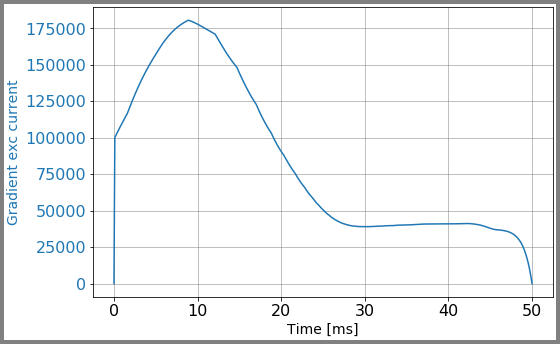

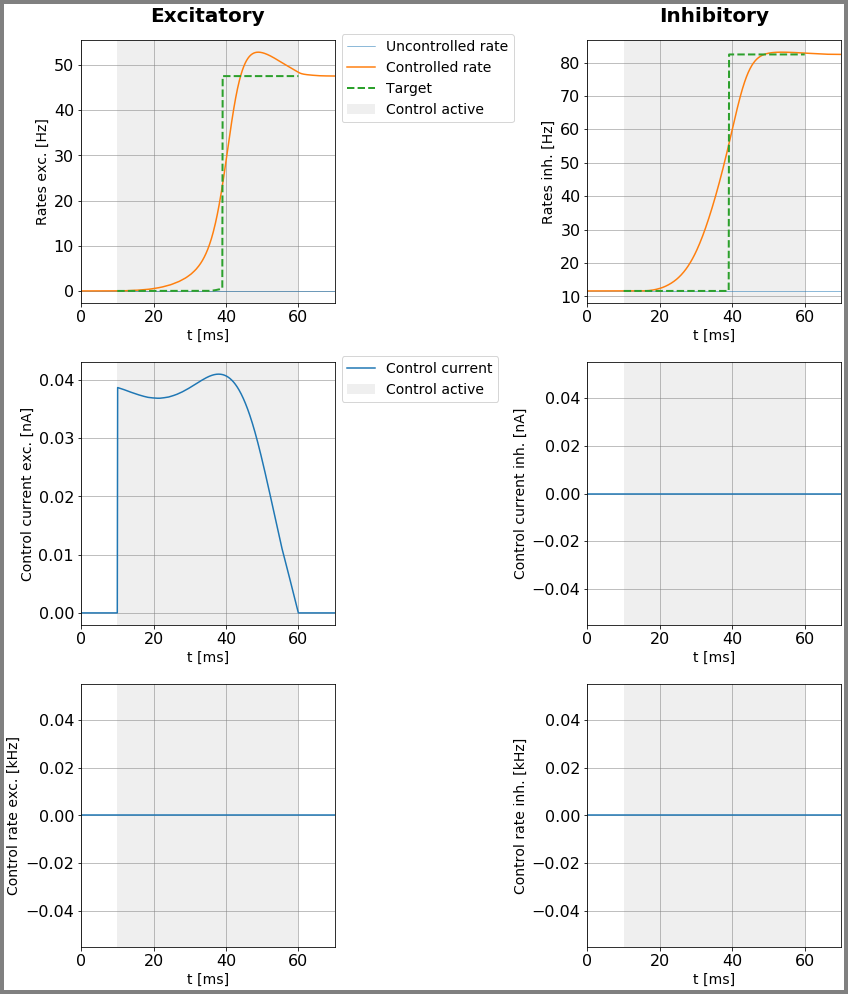

In [8]:
# define proper transition
start_ind = 250
trans_dur = 40
target_trans = target.copy()
target_trans[:,:,start_ind:start_ind+trans_dur+1] = bestStatea[:,:2,n_pre-1:n_pre + trans_dur]
target_trans[:,0,:start_ind] = target_trans[:,0,start_ind]
target_trans[:,1,:start_ind] = target_trans[:,1,start_ind]

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target_trans, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target_trans,
                      path, filename_ = case )

## 1

## 2

set cost params
control input:  [2] , precision measure:  [0]
RUN  0 , total integrated cost =  22605.96183341699
RUN  1 , total integrated cost =  5768.424536860836


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  5768.424536860836
Control only changes marginally.
RUN  2 , total integrated cost =  5768.424536860836
Improved over  2  iterations by  74.48272902799592  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7041354963196966
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.470984886936968
Problem in initial value trasfer:  Vmean_exc -56.18576769308551 -56.18528507168144


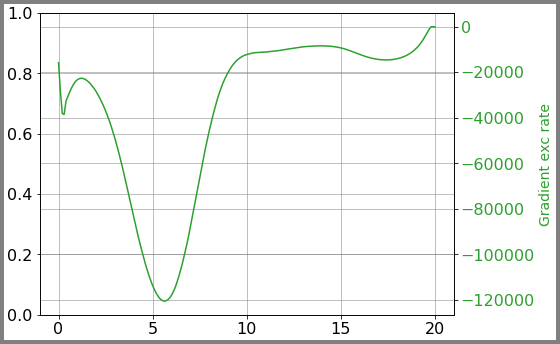

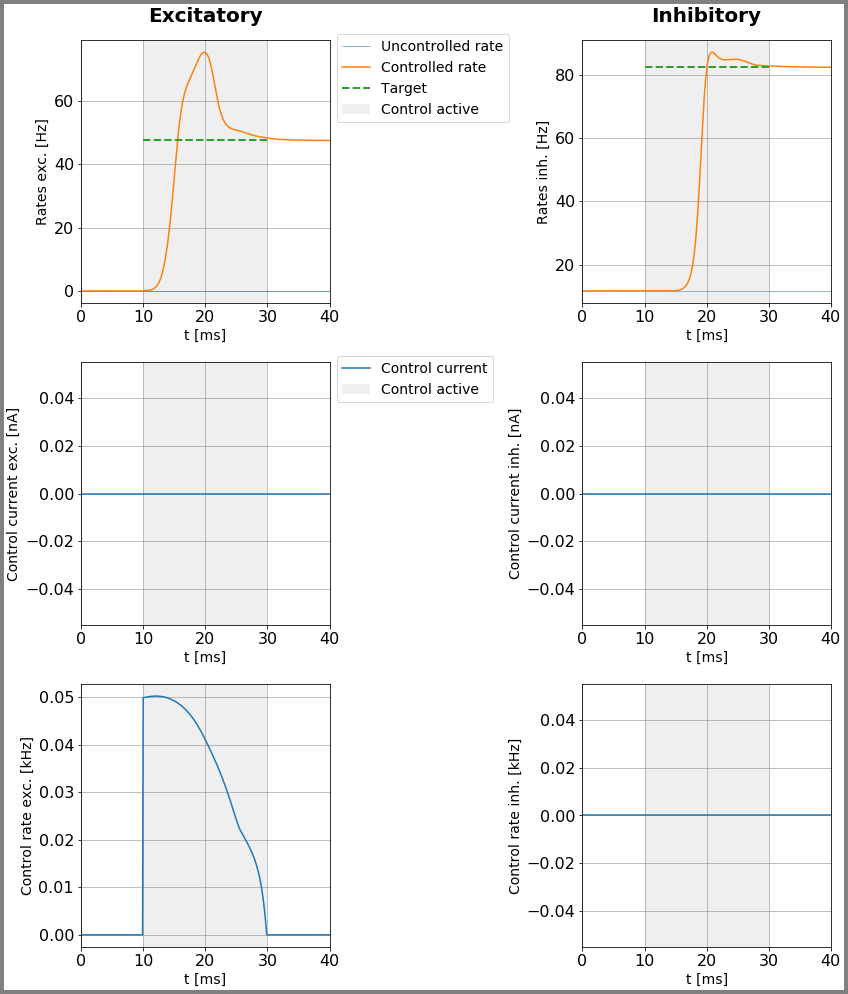

In [9]:
# A.0.a)

dur = 20
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

case_ind = 2
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
control input:  [2] , precision measure:  [0]
RUN  0 , total integrated cost =  16916.376262850943
RUN  1 , total integrated cost =  1807.189333061956
RUN  2 , total integrated cost =  1807.1893330619557
RUN  3 , total integrated cost =  1807.1893330619553
RUN  4 , total integrated cost =  1807.189333061955


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  1807.189333061955
Control only changes marginally.
RUN  5 , total integrated cost =  1807.189333061955
Improved over  5  iterations by  89.31692399730657  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7104426235367535
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.24795492928022
Problem in initial value trasfer:  Vmean_exc -56.180270978890206 -56.17997596764094


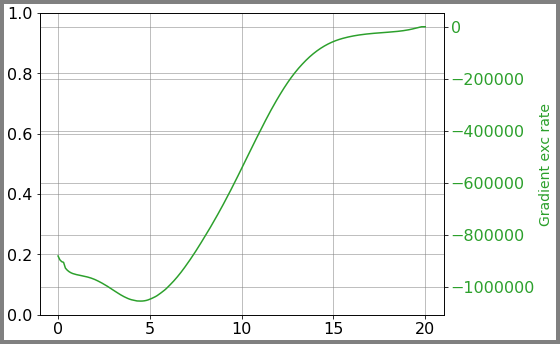

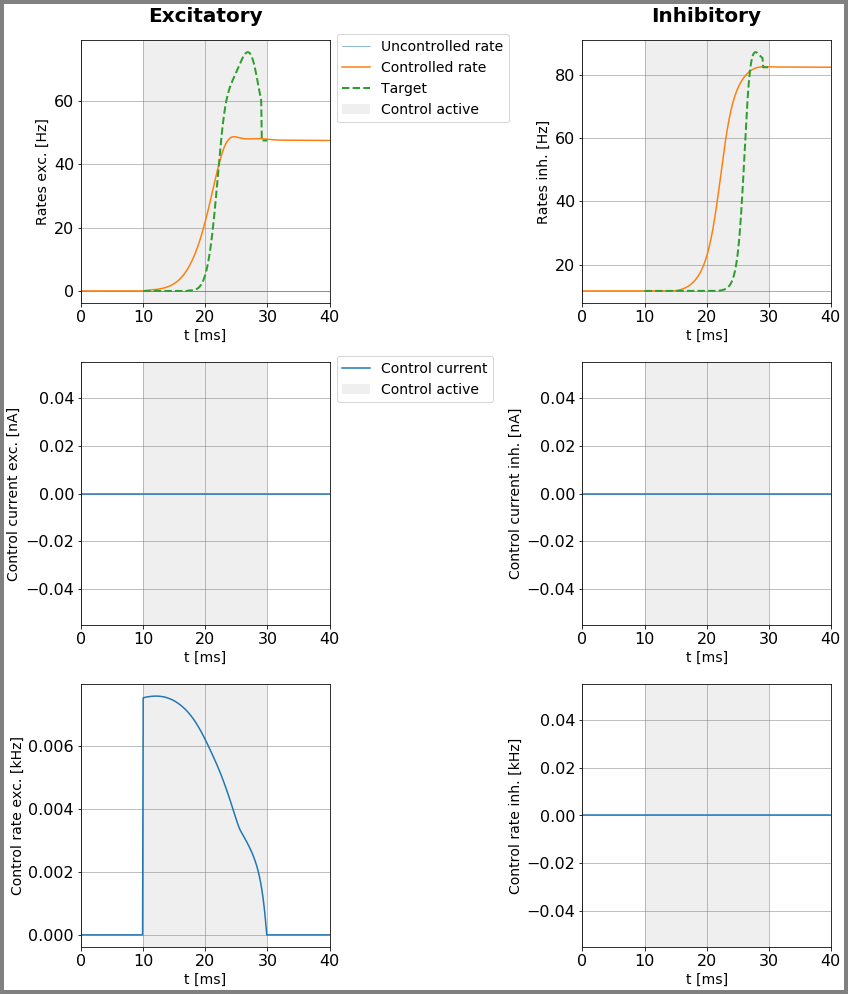

In [10]:
# define proper transition
start_ind = 70
trans_dur = 120
target_trans = target.copy()
target_trans[:,:,start_ind:start_ind+trans_dur+1] = bestStatea[:,:2,n_pre-1:n_pre + trans_dur]
target_trans[:,0,:start_ind] = target_trans[:,0,start_ind]
target_trans[:,1,:start_ind] = target_trans[:,1,start_ind]

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target_trans, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target_trans,
                      path, filename_ = case )

## 3

## 4

set cost params
control input:  [1] , precision measure:  [0]
RUN  0 , total integrated cost =  22605.96183341699
RUN  1 , total integrated cost =  12174.568170888031
RUN  2 , total integrated cost =  12152.767254096081
RUN  3 , total integrated cost =  12152.767254096078


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  12152.767254096078
Control only changes marginally.
RUN  4 , total integrated cost =  12152.767254096078
Improved over  4  iterations by  46.240875112283895  percent.
Problem in initial value trasfer:  Vmean_exc -56.216685523419486 -56.21574153032652


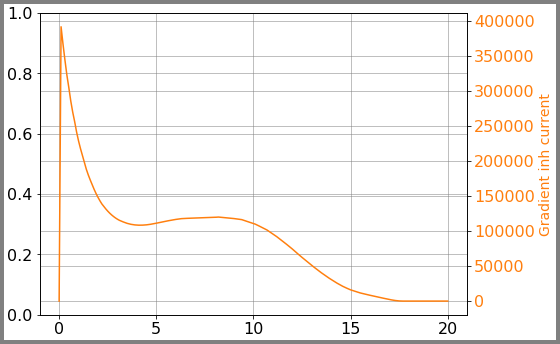

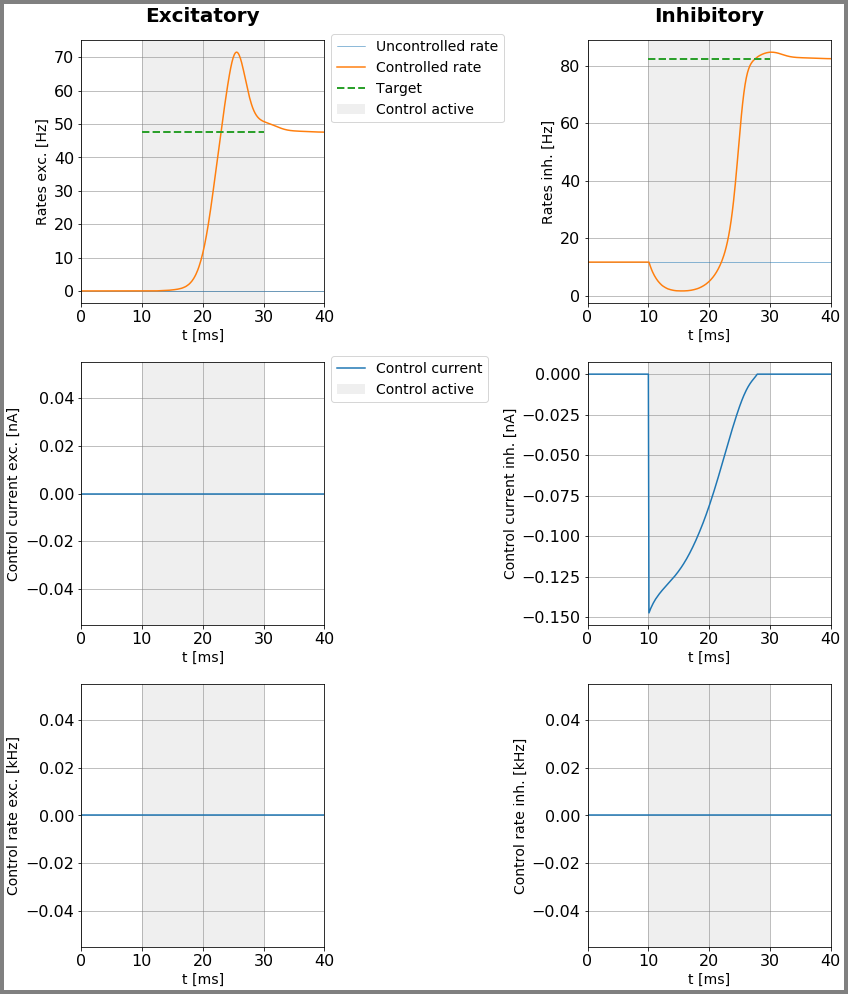

In [11]:
# A.4.a)

case_ind = 4
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  1700.5123588313795
RUN  1 , total integrated cost =  321.74267794187546
RUN  2 , total integrated cost =  289.1245662715206
RUN  3 , total integrated cost =  289.06080755192045
RUN  4 , total integrated cost =  289.06080755192016
RUN  5 , total integrated cost =  289.06080755191994


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  289.06080755191994
Control only changes marginally.
RUN  6 , total integrated cost =  289.06080755191994
Improved over  6  iterations by  83.0015462074873  percent.
Problem in initial value trasfer:  Vmean_exc -55.84040135624761 -55.85099335883115


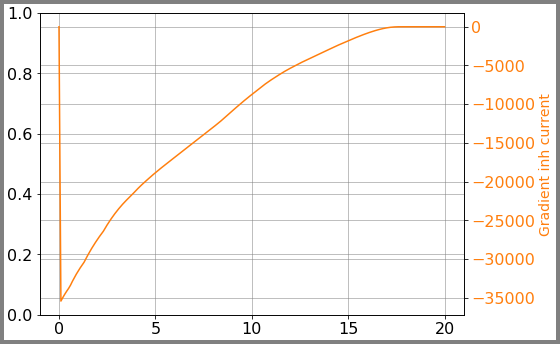

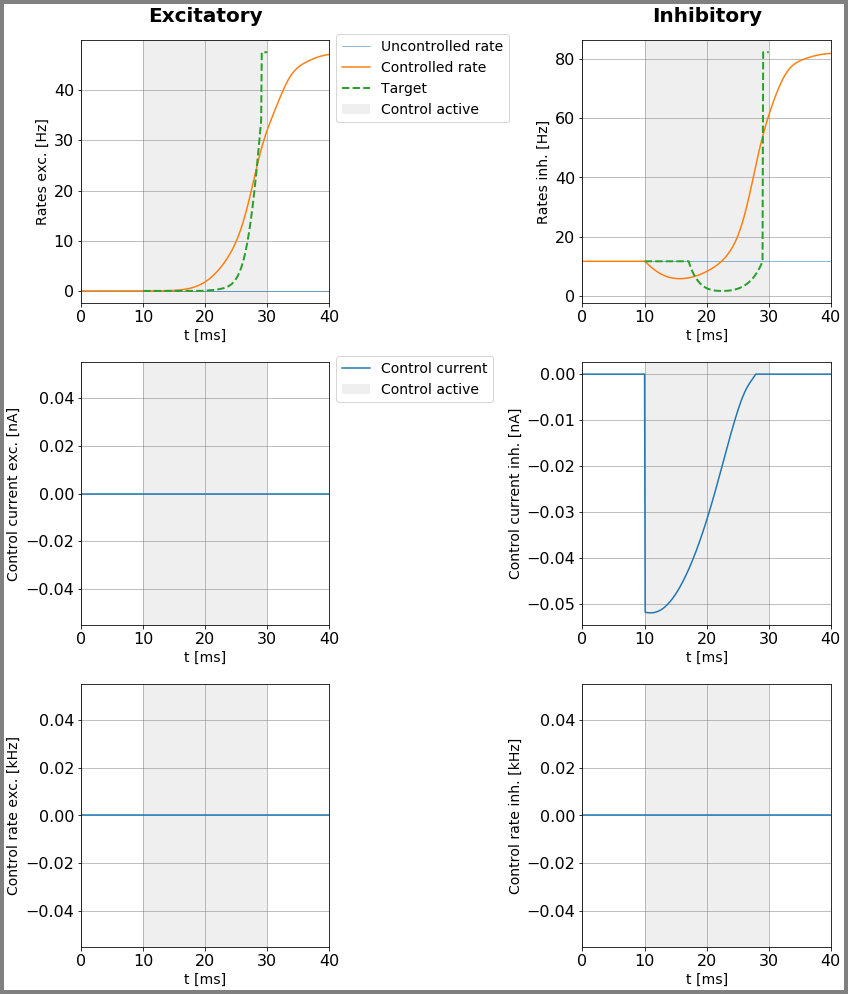

In [12]:
# define proper transition
start_ind = 70
trans_dur = 120
target_trans = target.copy()
target_trans[:,:,start_ind:start_ind+trans_dur+1] = bestStatea[:,:2,n_pre-1:n_pre + trans_dur]
target_trans[:,0,:start_ind] = target_trans[:,0,start_ind]
target_trans[:,1,:start_ind] = target_trans[:,1,start_ind]

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target_trans, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target_trans,
                      path, filename_ = case )

## 6

set cost params
control input:  [0, 1] , precision measure:  [0]
RUN  0 , total integrated cost =  22605.96183341699
RUN  1 , total integrated cost =  8484.97668487881
RUN  2 , total integrated cost =  8484.976684878808
RUN  3 , total integrated cost =  8484.976684878806


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  8484.976684878806
Control only changes marginally.
RUN  4 , total integrated cost =  8484.976684878806
Improved over  4  iterations by  62.465756832624606  percent.
Problem in initial value trasfer:  Vmean_exc -56.2231077322083 -56.220240421281474


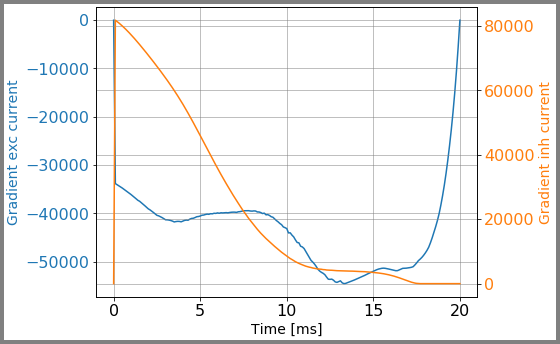

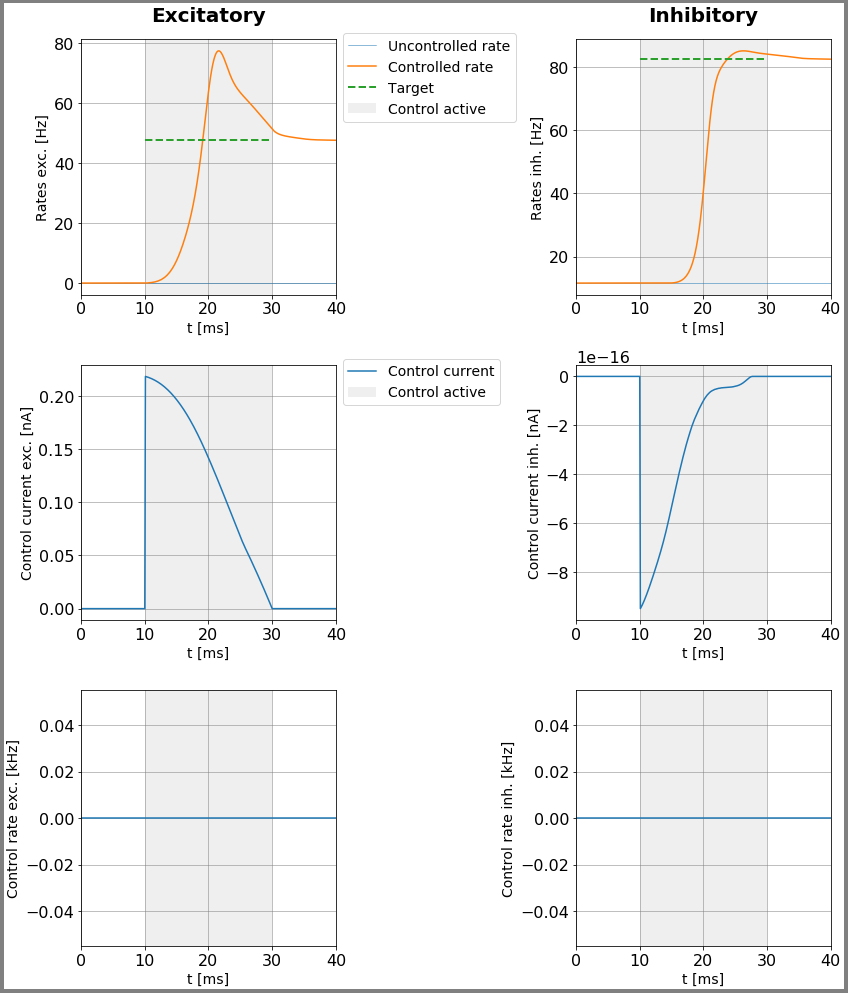

In [13]:
# A.6.a)
case_ind = 6
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)


bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  9474.162447888722
RUN  1 , total integrated cost =  659.4628885390504
RUN  2 , total integrated cost =  659.2960755878076
RUN  3 , total integrated cost =  659.2960755878063
RUN  4 , total integrated cost =  659.2960755878053
RUN  5 , total integrated cost =  659.2960755878049
RUN  6 , total integrated cost =  659.2960755878047


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  659.2960755878047
Control only changes marginally.
RUN  7 , total integrated cost =  659.2960755878047
Improved over  7  iterations by  93.04111493533946  percent.
Problem in initial value trasfer:  Vmean_exc -56.195602120063825 -56.194765039774154


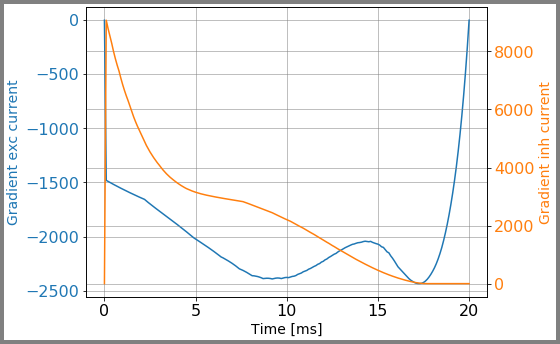

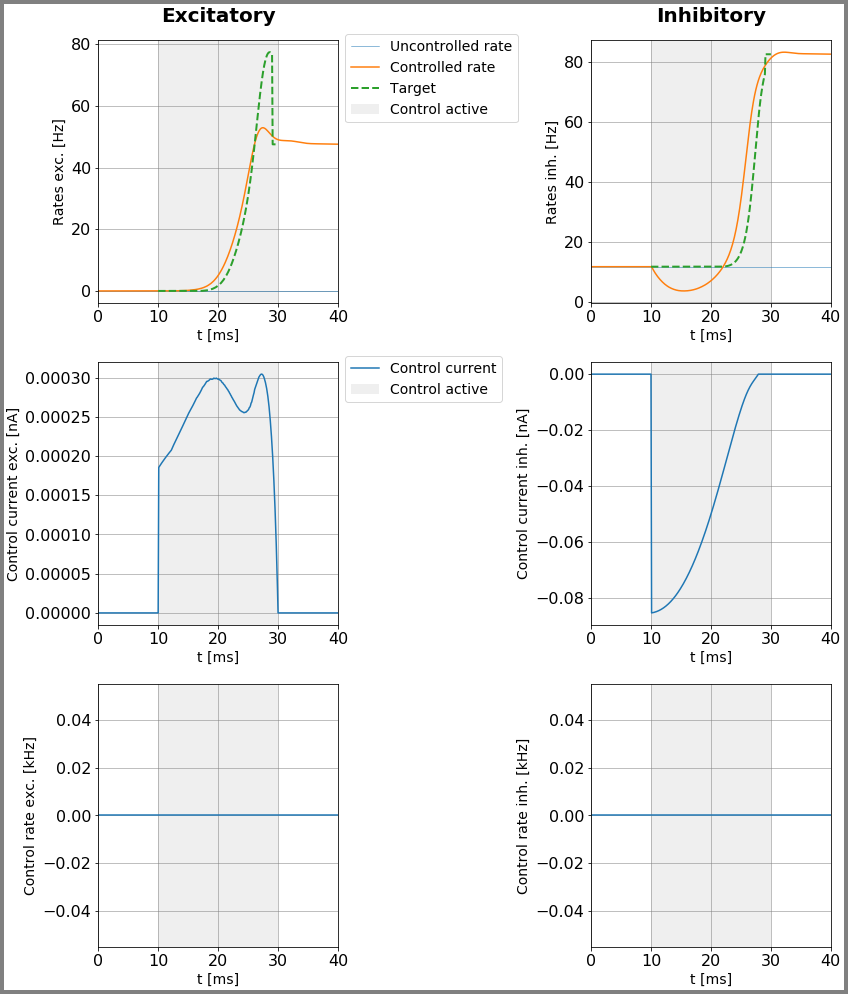

In [14]:
# define proper transition
start_ind = 70
trans_dur = 120
target_trans = target.copy()
target_trans[:,:,start_ind:start_ind+trans_dur+1] = bestStatea[:,:2,n_pre-1:n_pre + trans_dur]
target_trans[:,0,:start_ind] = target_trans[:,0,start_ind]
target_trans[:,1,:start_ind] = target_trans[:,1,start_ind]

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target_trans, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target_trans,
                      path, filename_ = case )

## 8

set cost params
control input:  [0, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  22605.96183341699
RUN  1 , total integrated cost =  5768.424536860836


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  5768.424536860836
Control only changes marginally.
RUN  2 , total integrated cost =  5768.424536860836
Improved over  2  iterations by  74.48272902799592  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7041354963196966
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.470984886936968
Problem in initial value trasfer:  Vmean_exc -56.18576769308551 -56.18528507168144


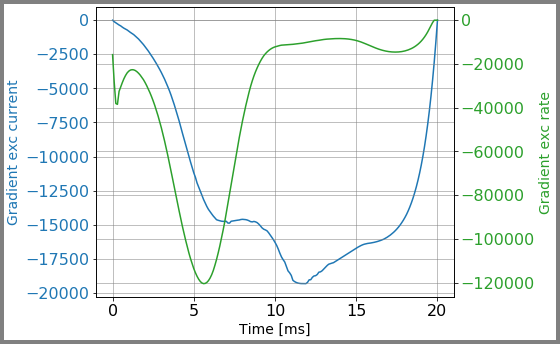

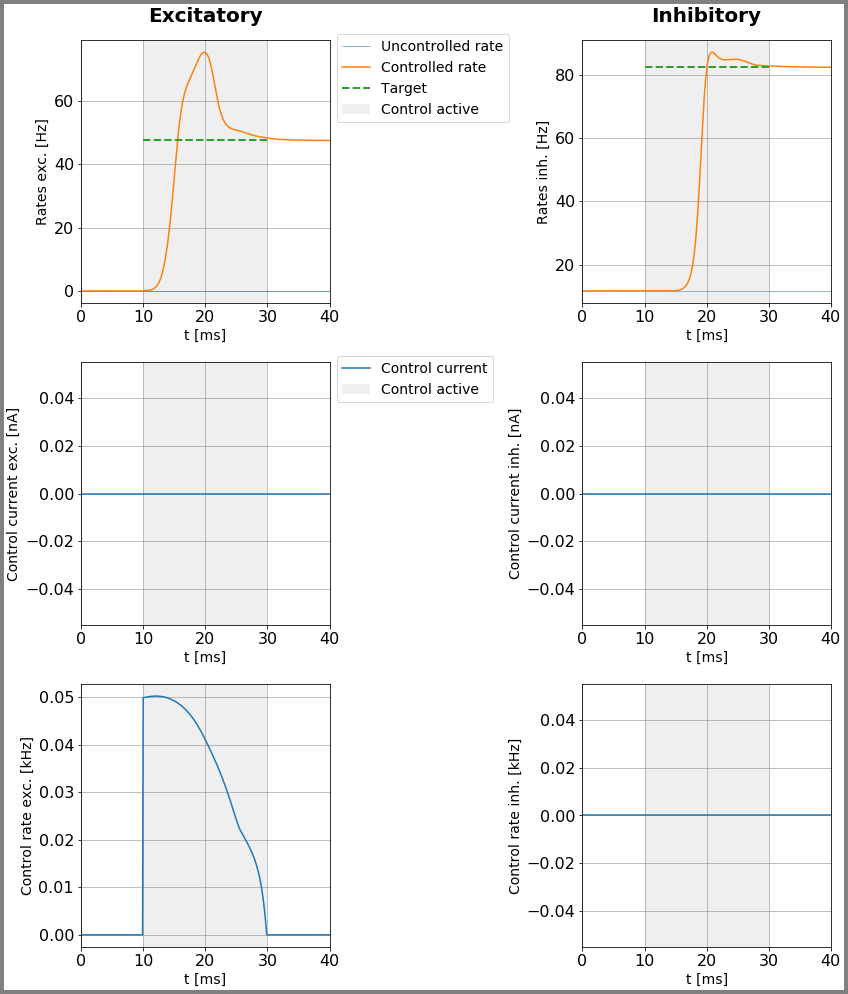

In [15]:
# A.8.a)
case_ind = 8
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  16916.376262850943
RUN  1 , total integrated cost =  1173.7849343078915
RUN  2 , total integrated cost =  1173.784934307891


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  1173.784934307891
Control only changes marginally.
RUN  3 , total integrated cost =  1173.784934307891
Improved over  3  iterations by  93.06125073083429  percent.
Problem in initial value trasfer:  Vmean_exc -56.21139165604015 -56.20917503336414


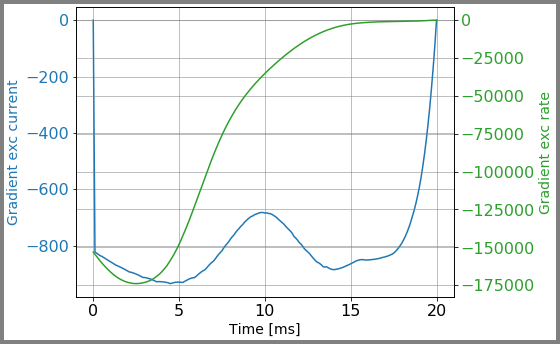

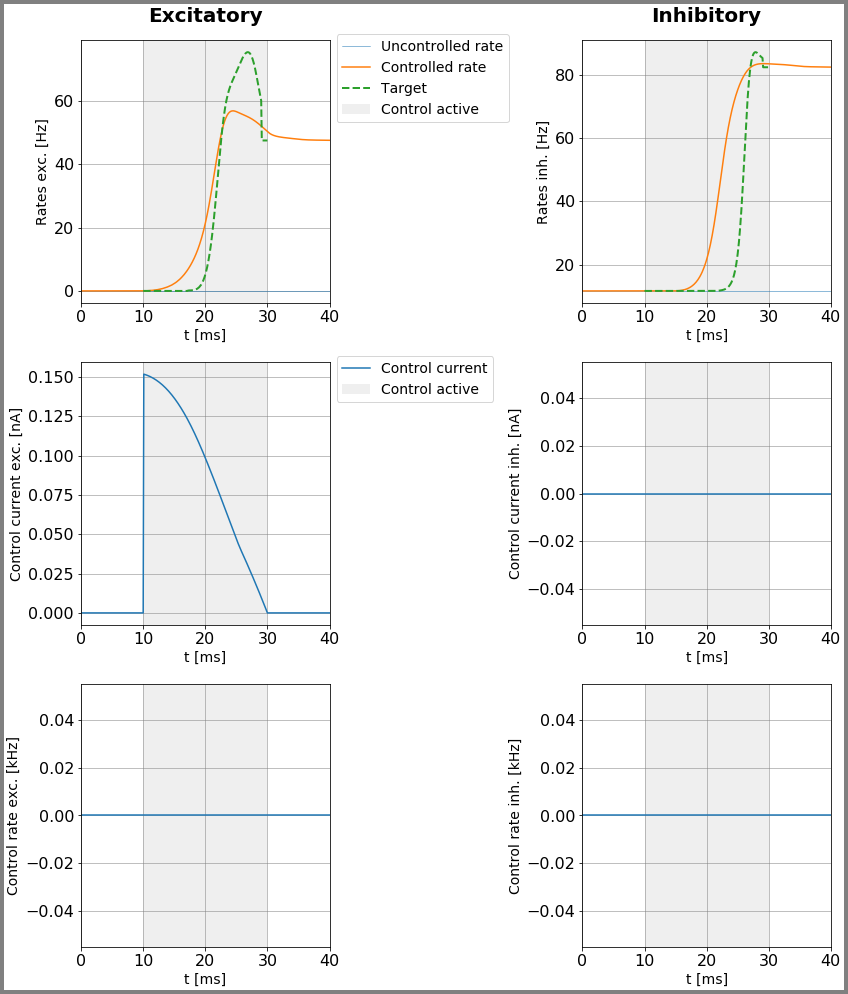

In [16]:
# define proper transition
start_ind = 70
trans_dur = 120
target_trans = target.copy()
target_trans[:,:,start_ind:start_ind+trans_dur+1] = bestStatea[:,:2,n_pre-1:n_pre + trans_dur]
target_trans[:,0,:start_ind] = target_trans[:,0,start_ind]
target_trans[:,1,:start_ind] = target_trans[:,1,start_ind]

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target_trans, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target_trans,
                      path, filename_ = case )

## 10

set cost params
control input:  [1, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  22605.96183341699
RUN  1 , total integrated cost =  5771.468426929556


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  5771.468426929556
Control only changes marginally.
RUN  2 , total integrated cost =  5771.468426929556
Improved over  2  iterations by  74.46926403990494  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7041354963196966
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.470984886936968
Problem in initial value trasfer:  Vmean_exc -56.185771709248904 -56.18528896816831


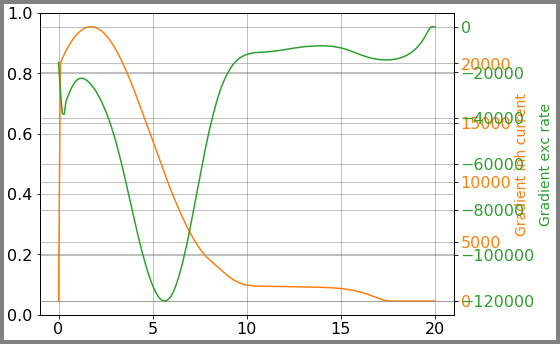

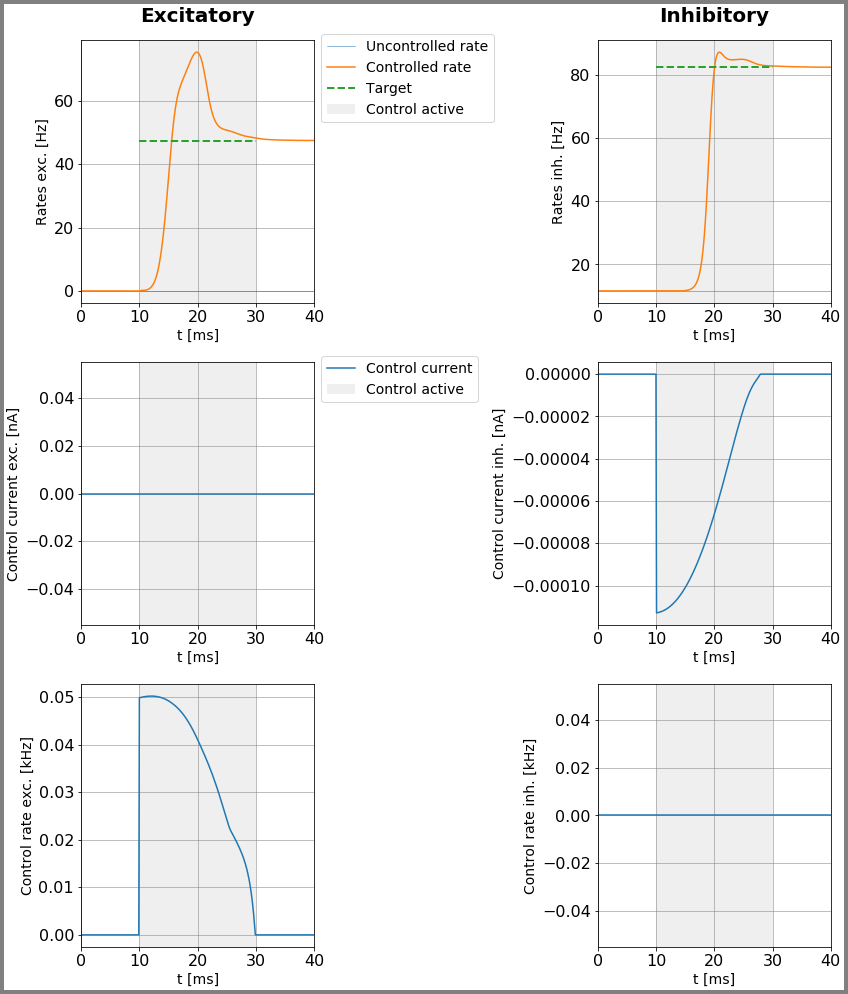

In [17]:
# A.10.a)
case_ind = 10
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  16926.91624095635
RUN  1 , total integrated cost =  335.1018342247756


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  335.1018342247756
Control only changes marginally.
RUN  2 , total integrated cost =  335.1018342247756
Improved over  2  iterations by  98.02030192945621  percent.
Problem in initial value trasfer:  Vmean_exc -56.21813336250257 -56.21716406789201


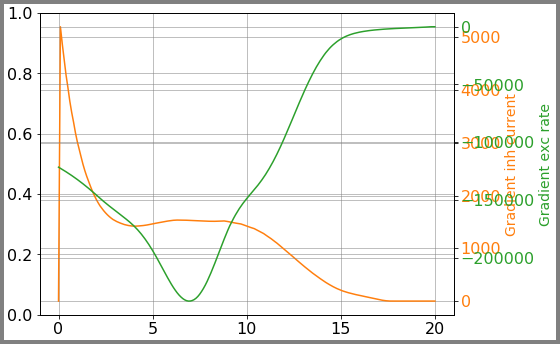

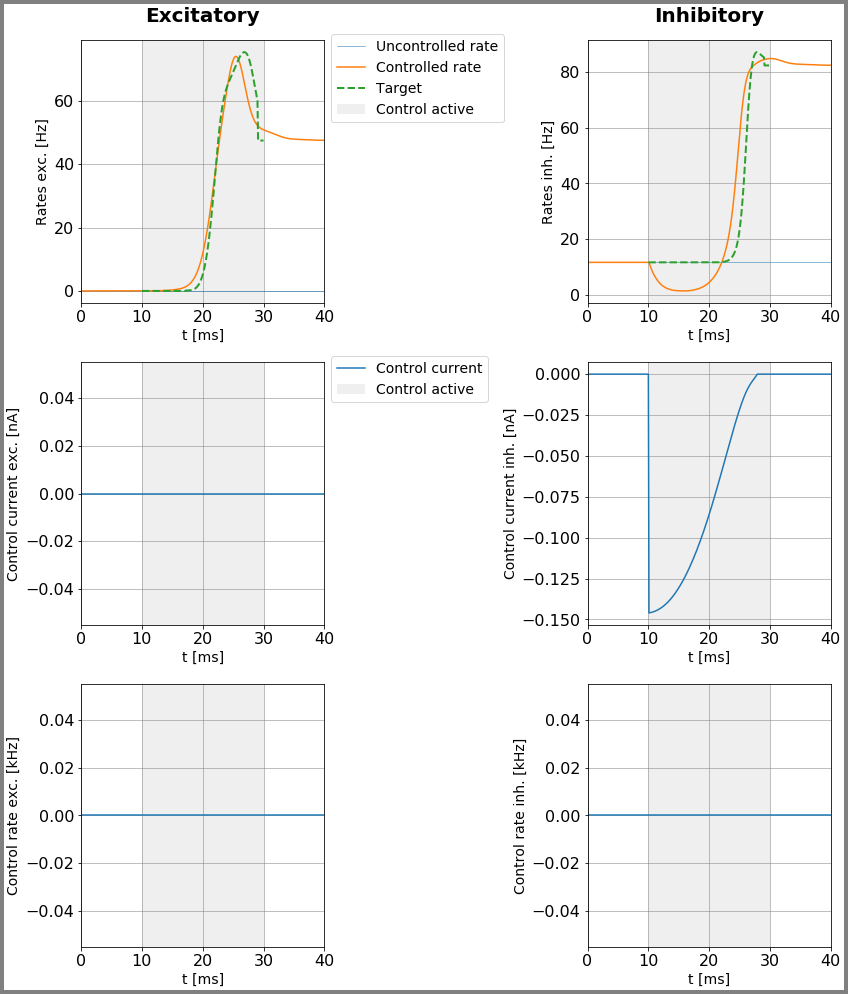

In [18]:
# define proper transition
start_ind = 70
trans_dur = 120
target_trans = target.copy()
target_trans[:,:,start_ind:start_ind+trans_dur+1] = bestStatea[:,:2,n_pre-1:n_pre + trans_dur]
target_trans[:,0,:start_ind] = target_trans[:,0,start_ind]
target_trans[:,1,:start_ind] = target_trans[:,1,start_ind]

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target_trans, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target_trans,
                      path, filename_ = case )

## 12

set cost params
control input:  [0, 1, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  22605.96183341699
RUN  1 , total integrated cost =  5768.424641398741
RUN  2 , total integrated cost =  5768.424641398739


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  5768.424641398739
Control only changes marginally.
RUN  3 , total integrated cost =  5768.424641398739
Improved over  3  iterations by  74.4827285655608  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7041354963196966
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.470984886936968
Problem in initial value trasfer:  Vmean_exc -56.18576769421678 -56.18528507274614


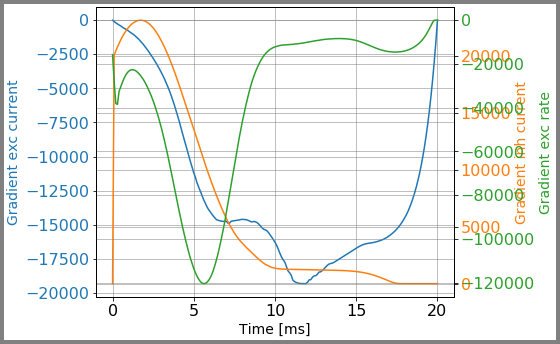

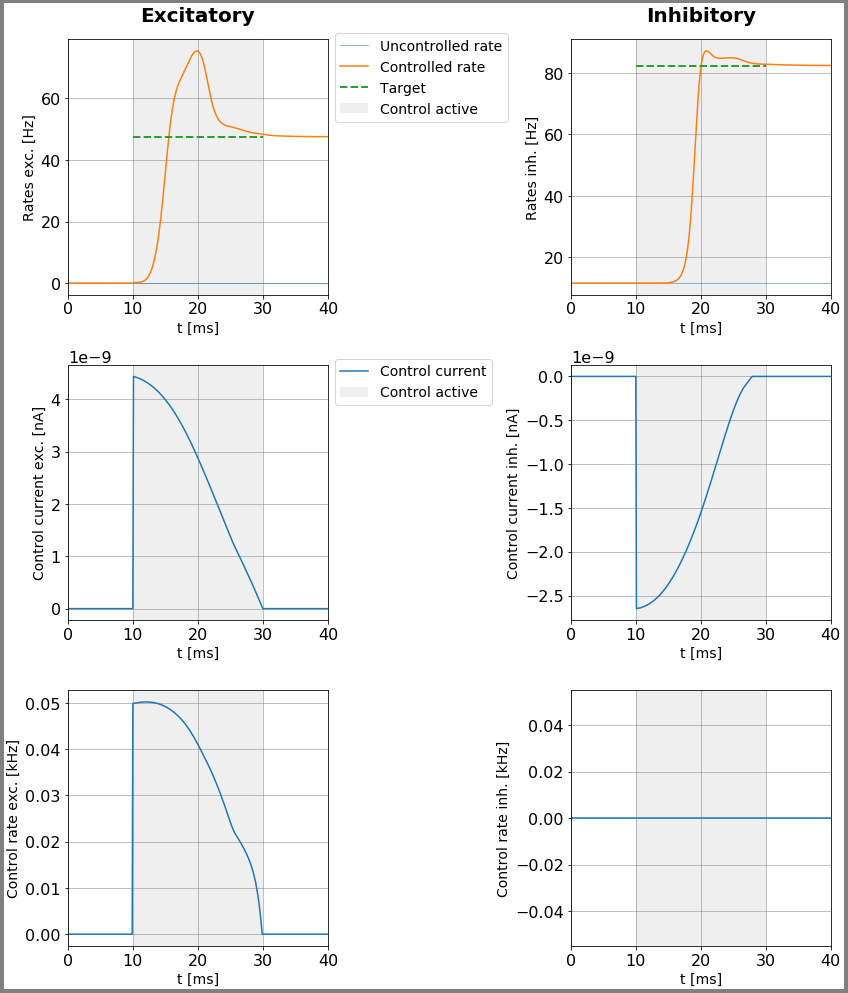

In [19]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  16916.376887655933
RUN  1 , total integrated cost =  334.35907070963924
RUN  2 , total integrated cost =  334.3590707096355
RUN  3 , total integrated cost =  334.35907070963515


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  334.35907070963515
Control only changes marginally.
RUN  4 , total integrated cost =  334.35907070963515
Improved over  4  iterations by  98.02345932033697  percent.
Problem in initial value trasfer:  Vmean_exc -56.218127455336244 -56.21715816505268


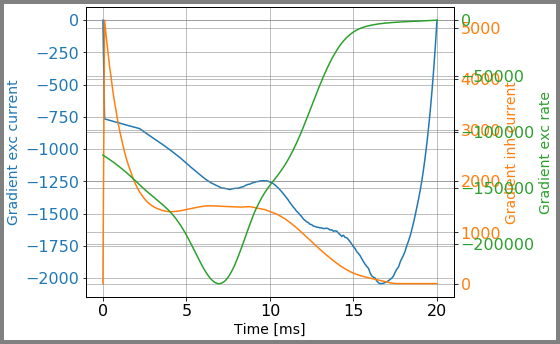

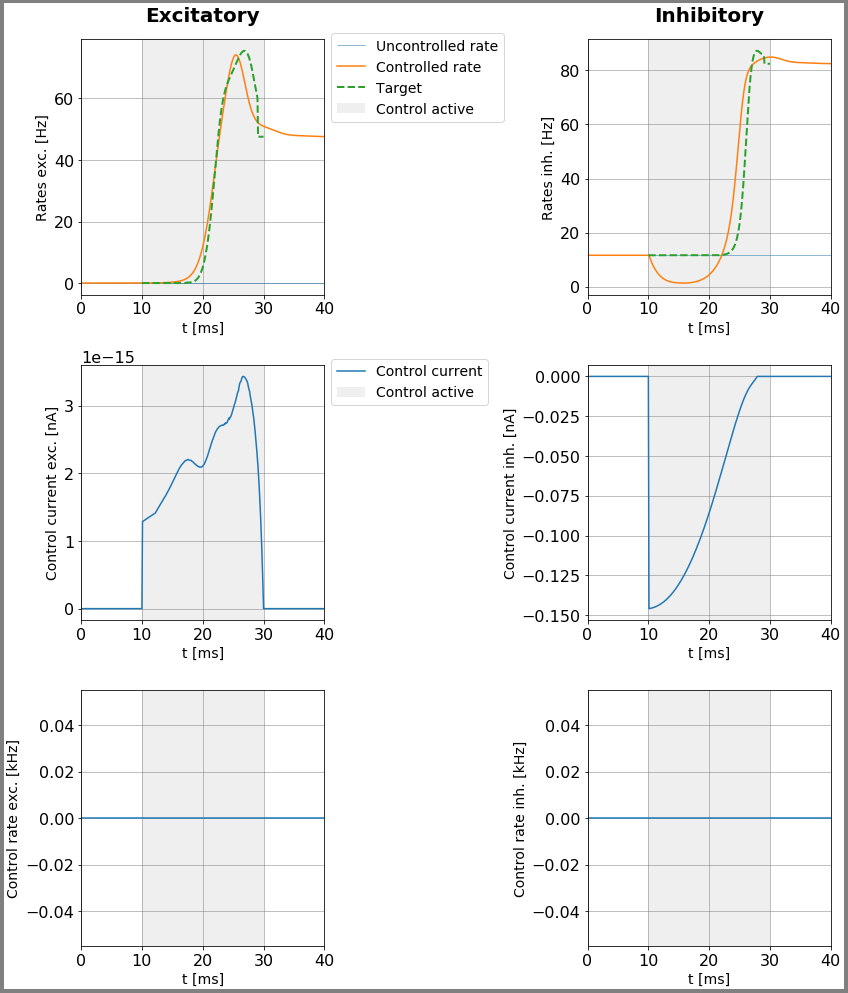

In [20]:
# define proper transition
start_ind = 70
trans_dur = 120
target_trans = target.copy()
target_trans[:,:,start_ind:start_ind+trans_dur+1] = bestStatea[:,:2,n_pre-1:n_pre + trans_dur]
target_trans[:,0,:start_ind] = target_trans[:,0,start_ind]
target_trans[:,1,:start_ind] = target_trans[:,1,start_ind]

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target_trans, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target_trans,
                      path, filename_ = case )